# XGBoost implementation

We will see the implementation and notes about XGBoost to our dataset

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

In [2]:
h_df = pd.read_csv('../data/treated_historic_data.csv', parse_dates=['date'], index_col=0)
f_df = pd.read_csv('../data/treated_forecast_data.csv', parse_dates=['date'], index_col=0)

In [3]:
h_df['d_type'] = 'Historic'
f_df['d_type'] = 'Forecast'
df_combined = pd.concat([h_df, f_df])

In [4]:
px.line(df_combined, y='temperature_2m_seville',
        title='Temperature in Seville', color='d_type',
        color_discrete_map={"Historic": "blue", "Forecast": "red"},
        labels={
            'date': 'Date',
            'temperature_2m_seville': 'Temperature (ºC)',
            'd_type': ''
            })


In [5]:
px.box(h_df, x='hour', y='temperature_2m_seville',
       title='Temperature boxplots for each hour',
       labels={
            'hour': 'Hour',
            'temperature_2m_seville': 'Temperature (ºC)'
            })

## Create model

In [67]:
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error

In [7]:
TARGET = 'temperature_2m_seville'
FEATURES = [f for f in h_df.columns if f not in [TARGET, 'd_type']]

X_train, y_train = h_df[FEATURES], h_df[TARGET]
X_test, y_test = f_df[FEATURES], f_df[TARGET]

In [15]:
reg = xgb.XGBRegressor(n_estimators=1000, 
                       early_stopping_rounds=50, # if the test set does not improve after 50 trees
                       learning_rate=0.1)
# n_estimators: number of trees
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:3.84989	validation_1-rmse:5.23035
[100]	validation_0-rmse:0.01585	validation_1-rmse:1.26891
[200]	validation_0-rmse:0.00250	validation_1-rmse:1.26665
[300]	validation_0-rmse:0.00079	validation_1-rmse:1.26643
[310]	validation_0-rmse:0.00079	validation_1-rmse:1.26643


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


Our training set begins to go down (first column, rmse), and our validation set starts to go down, and then gets worse and this is overfitting and this is what we would like to avoid. 'early_stopping_rounds' will stop our model once it sees this occurs in the model. We can lower the learning rate, to see if the model doesn't overfit too quickly

In [41]:
features_importances = pd.DataFrame(data=reg.feature_importances_,
                                    index=reg.feature_names_in_,
                                    columns=['importance'])

features_sorted = features_importances.sort_values('importance', ascending=False)

In [45]:
fig = px.bar(features_sorted.head(),
            x='importance',
            orientation='h',
            title='Top 5 most important coefficients (XGBoost Regression)',
            labels={'importance': 'Importance', 'index': 'Feature'}
        )
fig.show()

## Forecast on Test

In [47]:
f_df['prediction'] = reg.predict(X_test)

In [55]:
prediction_df = f_df[['temperature_2m_seville', 'prediction']]
prediction_df.head()

,temperature_2m_seville,prediction
date,,
2026-04-03 00:00:00+00:00,17.036999,17.885273
2026-04-03 01:00:00+00:00,15.837001,16.630245
2026-04-03 02:00:00+00:00,14.137000,15.547054
2026-04-03 03:00:00+00:00,12.737000,14.144460
2026-04-03 04:00:00+00:00,12.087001,12.537691


In [64]:
px.line(prediction_df, y=['temperature_2m_seville', 'prediction'],
        title='Comparison between real and predicted temperature',
        labels={
            'date': 'Date', 
            'value': 'Temperature (ºC)', 
            'variable': '',
            'temperature_2m_seville': 'Real',
            'prediction': 'Predicted'
        })

In [70]:
rmse = root_mean_squared_error(prediction_df['temperature_2m_seville'],
                   prediction_df['prediction'])
print(f'RMSE Score on Test set: {rmse:0.4f}')

RMSE Score on Test set: 1.2664


### Calculate Error

In [72]:
prediction_df['abs_err'] = np.abs(prediction_df[TARGET] - prediction_df['prediction'])

/var/folders/f9/wfy__0w50fs38x4mwcl58q6h0000gn/T/ipykernel_822/946539997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_df['abs_err'] = np.abs(prediction_df[TARGET] - prediction_df['prediction'])


In [73]:
prediction_df

,temperature_2m_seville,prediction,abs_err
date,,,
2026-04-03 00:00:00+00:00,17.036999,17.885273,0.848274
2026-04-03 01:00:00+00:00,15.837001,16.630245,0.793244
2026-04-03 02:00:00+00:00,14.137000,15.547054,1.410054
2026-04-03 03:00:00+00:00,12.737000,14.144460,1.407460
2026-04-03 04:00:00+00:00,12.087001,12.537691,0.450690
...,...,...,...
2026-04-08 19:00:00+00:00,12.156000,13.454872,1.298872
2026-04-08 20:00:00+00:00,12.106000,13.341339,1.235339
2026-04-08 21:00:00+00:00,11.606000,13.193781,1.587781


## Time Series Cross Validation

Not so useful...

In [74]:
from sklearn.model_selection import TimeSeriesSplit

In [90]:
tss = TimeSeriesSplit(n_splits=7, test_size=24, # hours in seven days
                      gap=0) # time between training and test data

df = df_combined

In [87]:
import matplotlib.pyplot as plt

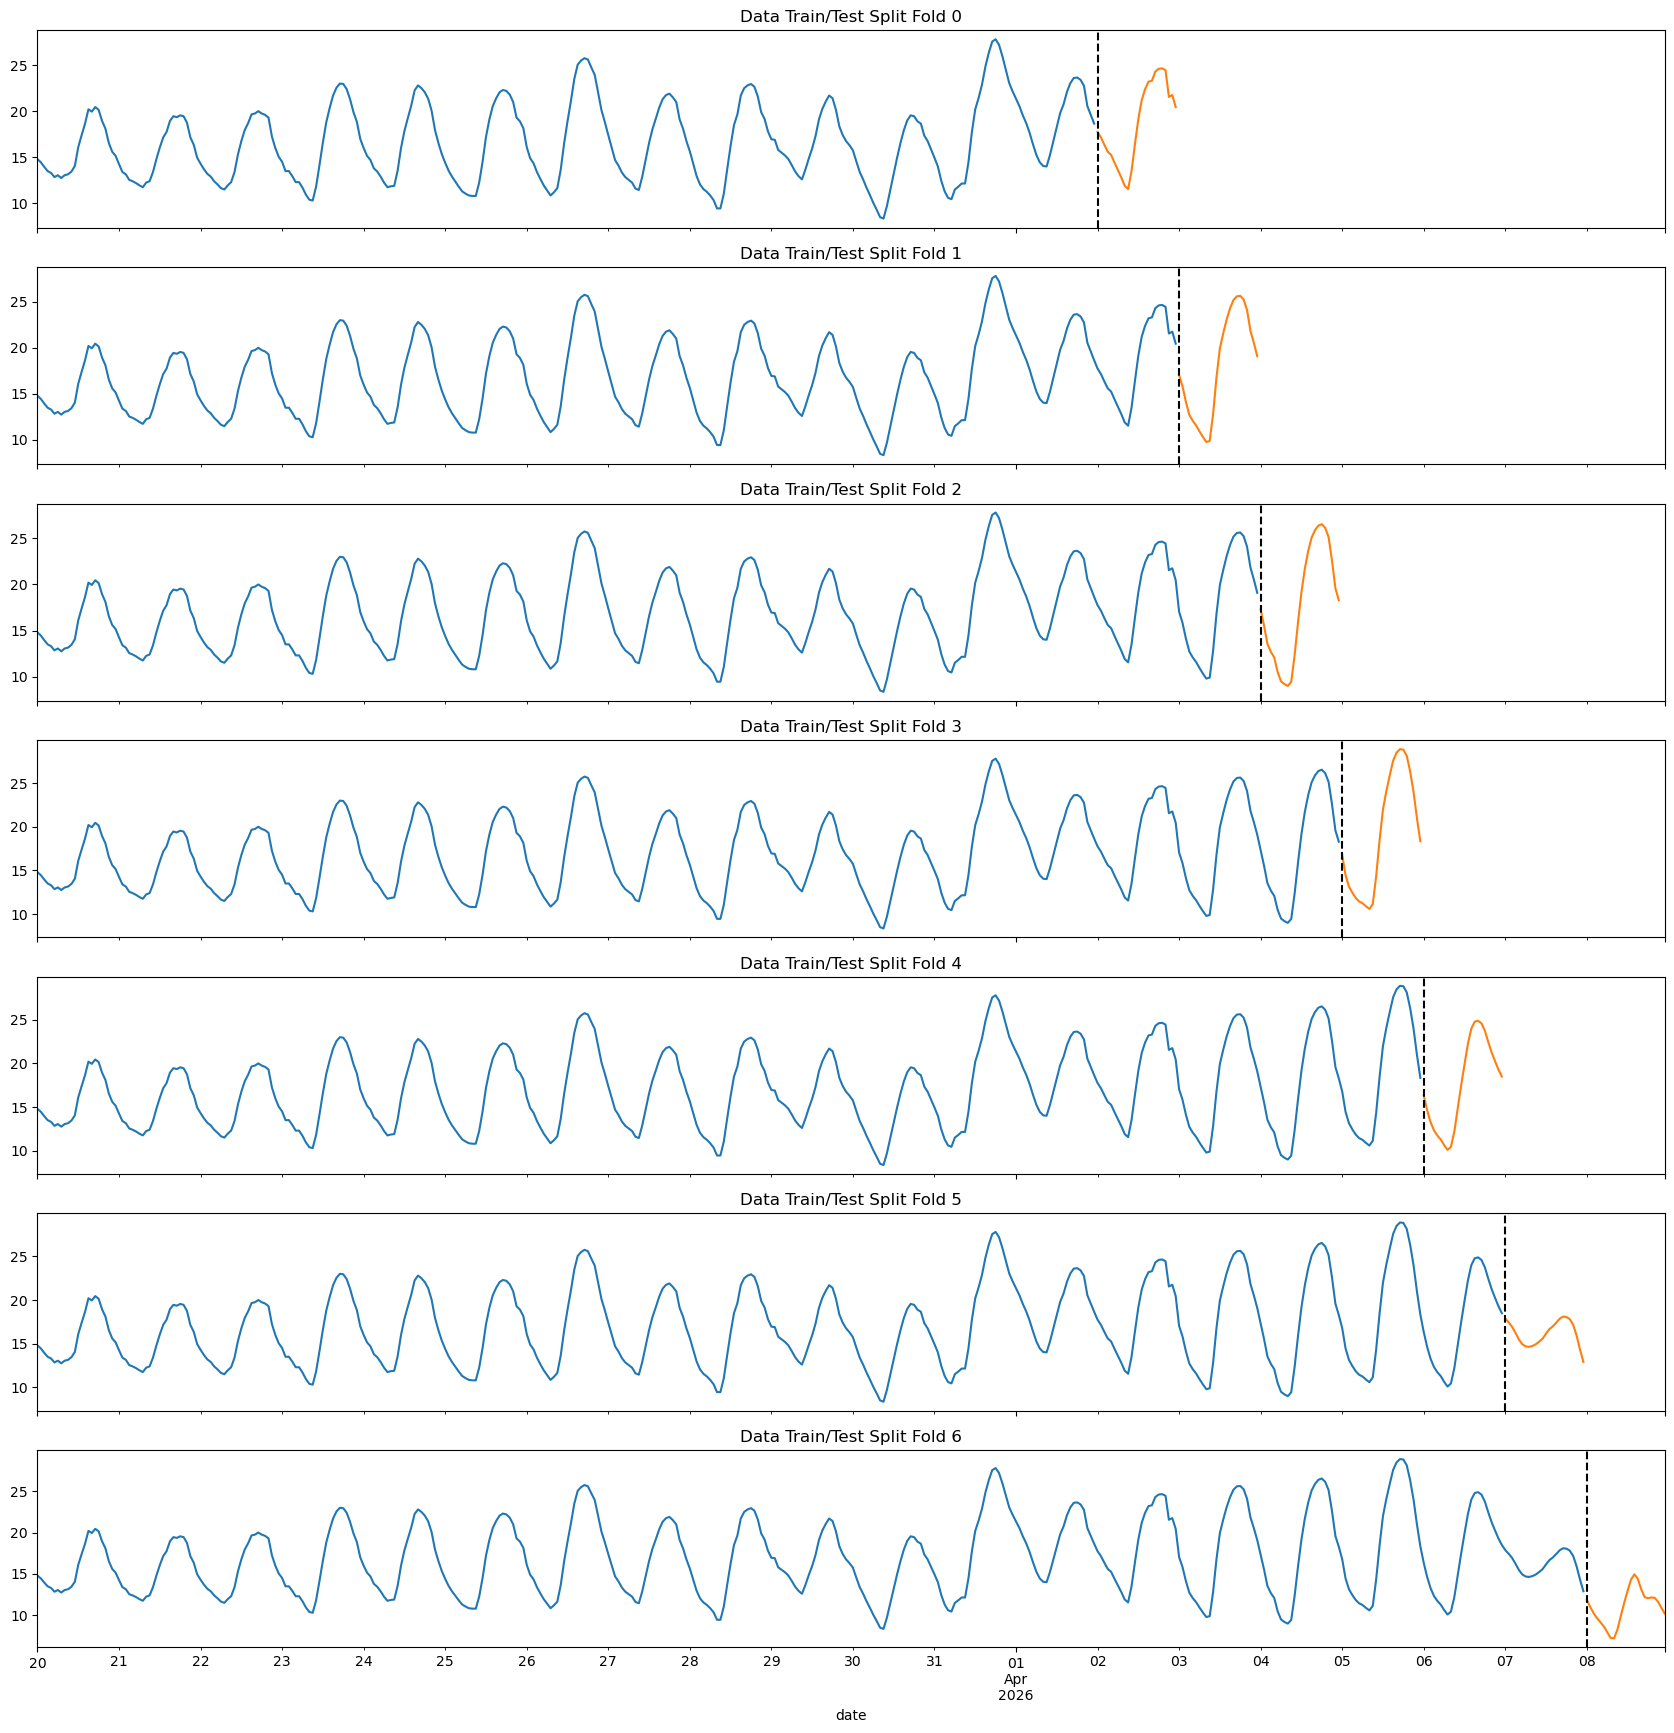

In [91]:
fig, axs = plt.subplots(7, 1, figsize=(21,21), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['temperature_2m_seville'].plot(ax=axs[fold],
                                         label='Training Set',
                                         title=f'Data Train/Test Split Fold {fold}')
    test['temperature_2m_seville'].plot(ax=axs[fold],
                                        label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

### Hypertuning

In [96]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

model = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

tscv = TimeSeriesSplit(n_splits=5)

gs = GridSearchCV(
    model,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)

gs.fit(X_train, y_train)

print("Mejores params:", gs.best_params_)
print("MAE en CV:", -gs.best_score_)

best_model = gs.best_estimator_
preds = best_model.predict(X_test)

Mejores params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
MAE en CV: 0.8217836563927786


In [ ]:
# best_model.save_model('xgboost.json')

In [99]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
r2   = r2_score(y_test, preds)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  1.0114
RMSE: 1.2224
R²:   0.9531


In [102]:
best_model.feature_importances_

array([2.21768332e-05, 1.34782487e-04, 1.53657038e-05, 3.61614293e-05,
       1.10905676e-04, 4.01228863e-05, 3.26823938e-05, 2.86894010e-05,
       1.02331769e-05, 1.68807026e-06, 4.77672620e-05, 9.05603738e-05,
       4.67713871e-05, 8.35702508e-07, 2.19341964e-05, 2.44644089e-05,
       1.90025501e-04, 3.96156211e-05, 7.04911188e-04, 1.11493595e-04,
       6.14176242e-05, 7.24843339e-05, 2.16547676e-04, 1.37419906e-03,
       4.85506716e-05, 1.39197582e-04, 2.16796354e-04, 1.04914550e-04,
       2.25723998e-04, 8.81736123e-05, 5.63222020e-05, 2.23510363e-03,
       3.87508273e-02, 2.67587304e-01, 4.34085960e-03, 2.72657096e-01,
       1.17409587e-01, 2.97042634e-03, 3.34325735e-03, 1.27833700e-04,
       4.85967466e-05, 2.33067010e-04, 2.63931259e-04, 1.03716309e-04,
       1.20426514e-04, 2.73277867e-04, 1.03375925e-04, 1.54801775e-04,
       6.90876623e-04, 1.55067028e-04, 7.39135576e-05, 1.96800815e-04,
       1.36622519e-04, 3.06978880e-04, 2.46518000e-04, 6.51562703e-04,
      

In [103]:
best_model.feature_names_in_

array(['cloud_cover_badajoz', 'cloud_cover_c_real', 'cloud_cover_cadiz',
       'cloud_cover_cordoba', 'cloud_cover_huelva', 'cloud_cover_lisbon',
       'cloud_cover_malaga', 'cloud_cover_seville',
       'precipitation_badajoz', 'precipitation_c_real',
       'precipitation_cadiz', 'precipitation_cordoba',
       'precipitation_huelva', 'precipitation_lisbon',
       'precipitation_malaga', 'precipitation_seville',
       'pressure_msl_badajoz', 'pressure_msl_c_real',
       'pressure_msl_cadiz', 'pressure_msl_cordoba',
       'pressure_msl_huelva', 'pressure_msl_lisbon',
       'pressure_msl_malaga', 'pressure_msl_seville',
       'relative_humidity_2m_badajoz', 'relative_humidity_2m_c_real',
       'relative_humidity_2m_cadiz', 'relative_humidity_2m_cordoba',
       'relative_humidity_2m_huelva', 'relative_humidity_2m_lisbon',
       'relative_humidity_2m_malaga', 'relative_humidity_2m_seville',
       'temperature_2m_badajoz', 'temperature_2m_c_real',
       'temperature_2m_cadiz'